# Library Wetterdienst

## Install

The library Wetterdienst needs to be install first. I suggest you create a python environment using the command python -m venv henv. After the environment has been created you need to activate it with <env-name>\Scripts\activate. Windows might not allow you to run it in the Power-Shell. Youse the Command Line Editor instead. When the environment is activate, it is shown before your prompt. 

In your CLI you run pip install wetterdienst. You might have to install pandas as well with pip install pandas. You also need to install jupyter notebook with the command pip install jupyter notebook.

In [40]:
import datetime as dt
from wetterdienst.provider.dwd.observation import DwdObservationRequest

request = DwdObservationRequest(
    parameters=("daily", "precipitation_more"),
    start_date=dt.datetime(2020, 1, 1),
    end_date=dt.datetime(2020, 1, 20)
)
stations = request.filter_by_name(name="Lübeck-Blankensee")
dfs = stations.df

In [6]:
# importing the modules
from IPython.display import display
import pandas as pd

# creating a DataFrame
dict = {'Name' : ['Martha', 'Tim', 'Rob', 'Georgia'],
        'Maths' : [87, 91, 97, 95],
        'Science' : [83, 99, 84, 76]}
df = pd.DataFrame(dict)

# displaying the DataFrame
display(df)

,Name,Maths,Science
0,Martha,87,83
1,Tim,91,99
2,Rob,97,84
3,Georgia,95,76


In [7]:
display(dfs)

resolution,dataset,station_id,start_date,end_date,latitude,longitude,height,name,state
str,str,str,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,str,str
"""daily""","""precipitation_more""","""03086""",1985-03-01 00:00:00 UTC,2026-04-27 00:00:00 UTC,53.8025,10.6989,15.0,"""Lübeck-Blankensee""","""Schleswig-Holstein"""


## Download Station data

In [8]:
from wetterdienst.provider.dwd.observation import DwdObservationRequest

metadata = DwdObservationRequest.discover(
    resolutions="daily",
)

metadata

{'daily': {'climate_summary': [{'name': 'wind_gust_max',
    'name_original': 'fx',
    'unit_type': 'speed',
    'unit': 'meter_per_second'},
   {'name': 'wind_speed',
    'name_original': 'fm',
    'unit_type': 'speed',
    'unit': 'meter_per_second'},
   {'name': 'precipitation_height',
    'name_original': 'rsk',
    'unit_type': 'precipitation',
    'unit': 'millimeter'},
   {'name': 'precipitation_form',
    'name_original': 'rskf',
    'unit_type': 'dimensionless',
    'unit': 'dimensionless'},
   {'name': 'sunshine_duration',
    'name_original': 'sdk',
    'unit_type': 'time',
    'unit': 'hour'},
   {'name': 'snow_depth',
    'name_original': 'shk_tag',
    'unit_type': 'length_short',
    'unit': 'centimeter'},
   {'name': 'cloud_cover_total',
    'name_original': 'nm',
    'unit_type': 'fraction',
    'unit': 'one_eighth'},
   {'name': 'pressure_vapor',
    'name_original': 'vpm',
    'unit_type': 'pressure',
    'unit': 'hectopascal'},
   {'name': 'pressure_air_site',
    

We now get daily precipitation.

In [18]:
from wetterdienst.provider.dwd.observation import DwdObservationRequest

request = DwdObservationRequest(
    parameters=("daily", "precipitation_more"),
    periods="historical",
)

stations = request.all()
df = stations.df
df

resolution,dataset,station_id,start_date,end_date,latitude,longitude,height,name,state
str,str,str,"datetime[μs, UTC]","datetime[μs, UTC]",f64,f64,f64,str,str
"""daily""","""precipitation_more""","""00001""",1912-01-01 00:00:00 UTC,1986-06-30 00:00:00 UTC,47.8413,8.8493,478.0,"""Aach""","""Baden-Württemberg"""
"""daily""","""precipitation_more""","""00002""",1951-01-01 00:00:00 UTC,2006-12-31 00:00:00 UTC,50.8066,6.0996,138.0,"""Aachen (Kläranlage)""","""Nordrhein-Westfalen"""
"""daily""","""precipitation_more""","""00003""",1891-01-01 00:00:00 UTC,2011-03-31 00:00:00 UTC,50.7827,6.0941,202.0,"""Aachen""","""Nordrhein-Westfalen"""
"""daily""","""precipitation_more""","""00004""",1951-01-01 00:00:00 UTC,1979-10-31 00:00:00 UTC,50.7683,6.1207,243.0,"""Aachen-Brand""","""Nordrhein-Westfalen"""
"""daily""","""precipitation_more""","""00006""",1982-11-01 00:00:00 UTC,2026-04-27 00:00:00 UTC,48.8361,10.0598,455.0,"""Aalen-Unterrombach""","""Baden-Württemberg"""
…,…,…,…,…,…,…,…,…,…
"""daily""","""precipitation_more""","""19995""",2024-08-01 00:00:00 UTC,2026-04-27 00:00:00 UTC,54.0659,10.6502,40.0,"""Süsel-Kesdorf""","""Schleswig-Holstein"""
"""daily""","""precipitation_more""","""19998""",1936-07-01 00:00:00 UTC,1965-11-29 00:00:00 UTC,51.712,10.6684,540.0,"""Wietfeld (Harz)""","""Sachsen-Anhalt"""
"""daily""","""precipitation_more""","""20003""",2024-11-01 00:00:00 UTC,2026-04-26 00:00:00 UTC,48.0764,9.0221,607.0,"""Beuron-Langenbrunn""","""Baden-Württemberg"""


Now, we get the data for a dataset.

In [19]:
from wetterdienst.provider.dwd.observation import DwdObservationRequest

request = DwdObservationRequest(
    parameters=("daily", "kl", "rsk"),
    start_date=dt.datetime(2000, 1, 1),
    end_date=dt.datetime(2020, 1, 20)
)
stations = request.filter_by_name(name="Lübeck-Blankensee")
df = stations.df

# From here you can query data by station
for result in stations.values.query():
    # analyse the station here
    break

df = result.df.drop_nulls()
df

station_id,resolution,dataset,parameter,date,value,quality
str,str,str,str,"datetime[μs, UTC]",f64,f64
"""03086""","""daily""","""climate_summary""","""precipitation_height""",2000-01-01 00:00:00 UTC,1.7,10.0
"""03086""","""daily""","""climate_summary""","""precipitation_height""",2000-01-02 00:00:00 UTC,0.0,10.0
"""03086""","""daily""","""climate_summary""","""precipitation_height""",2000-01-03 00:00:00 UTC,4.3,10.0
"""03086""","""daily""","""climate_summary""","""precipitation_height""",2000-01-04 00:00:00 UTC,2.8,10.0
"""03086""","""daily""","""climate_summary""","""precipitation_height""",2000-01-05 00:00:00 UTC,0.0,10.0
…,…,…,…,…,…,…
"""03086""","""daily""","""climate_summary""","""precipitation_height""",2020-01-16 00:00:00 UTC,0.0,9.0
"""03086""","""daily""","""climate_summary""","""precipitation_height""",2020-01-17 00:00:00 UTC,0.7,9.0
"""03086""","""daily""","""climate_summary""","""precipitation_height""",2020-01-18 00:00:00 UTC,0.0,9.0


## Plotting the data

We need to install and then load libraries for plotting. 

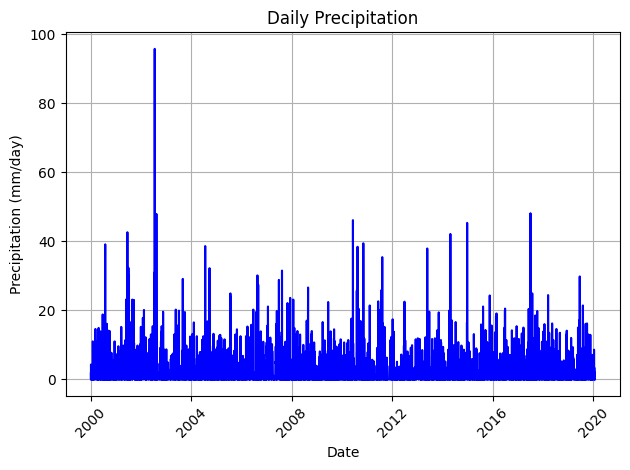

In [25]:
import numpy as np
import matplotlib.pyplot as plt
# Precipitation data
plt.plot(df["date"], df["value"], linestyle='-', color='blue')
plt.title('Daily Precipitation')
plt.xlabel('Date')
plt.ylabel('Precipitation (mm/day)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

### Cumulative precipitation

The cumulated precipitation shows gradients and biases.

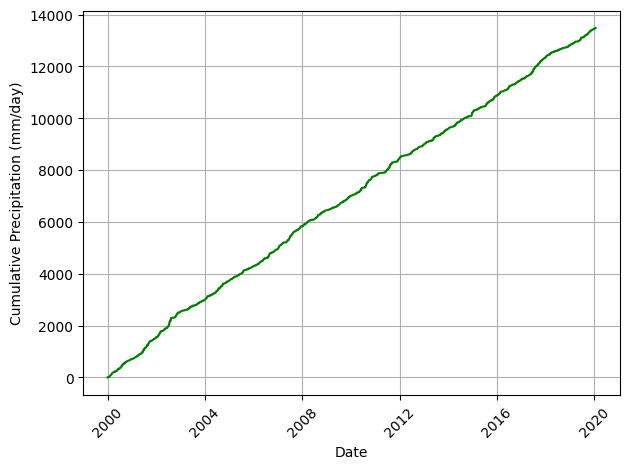

In [33]:
import numpy as np
import pandas as pds
pdate = df["date"];
prec = df["value"];
precSeries = pds.Series(prec);
cumulativeprec = precSeries.cumsum();
plt.plot(pdate, cumulativeprec, label='Cumulative Precipitation', color='green') 
plt.xlabel('Date')
plt.ylabel('Cumulative Precipitation (mm/day)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## Standard Precipitation Index

We will calculate the precipitation index.

In [39]:
import pandas as pd
from standard_precip.spi import SPI

# Initialize SPI class
spi = SPI()

# create series data frame
dfs = pd.DataFrame(pdate,precSeries,
                  columns=['Date', 'Prec'])

# Calculate SPI using Gamma distribution and L-moments
df_spi = spi.calculate(
df,
date_col=Date,
precip_col=Prec,
freq="D",
scale=1,
fit_type="lmom",
dist_type="gam"
)

print(df_spi.head())

ValueError: Shape of passed values is (7291, 1), indices imply (7291, 2)